In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


%matplotlib inline

In [186]:
df = pd.read_csv('d:/ML/Project/creditcard.csv')

In [187]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [189]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Target Variable Distribution


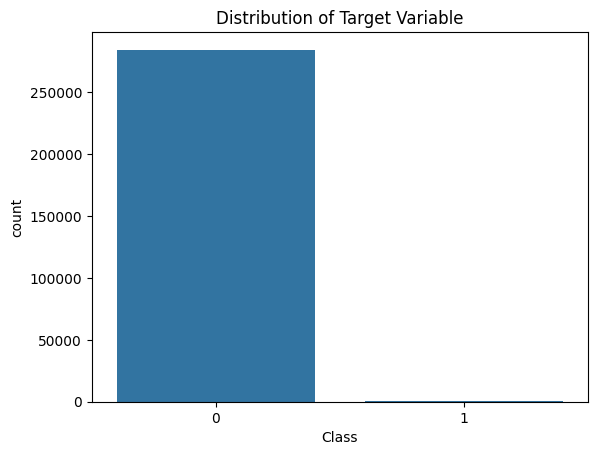

In [190]:
print("Target Variable Distribution")
sns.countplot(x="Class",data=df)
plt.title("Distribution of Target Variable")
plt.show()

In [191]:
non_fraud=df[df.Class==0]
fraud=df[df.Class==1]

In [192]:
print(non_fraud.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [193]:
non_fraud.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [194]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [195]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [196]:
non_fraud_sample=non_fraud.sample(n=492)

In [197]:
new_df=pd.concat([non_fraud_sample,fraud],axis=0)

In [198]:
new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
18623,29643.0,-0.908505,1.161986,1.928416,0.497961,-0.530008,-0.192915,0.096970,0.527777,-0.832962,...,-0.131507,-0.364673,-0.159579,0.574868,0.147281,0.284884,-0.079363,0.001679,0.00,0
18729,29722.0,-1.498993,-0.697464,2.134103,-1.849660,-1.726847,-0.278327,0.968879,-0.075855,1.814966,...,0.045525,0.590016,0.110951,0.791598,0.714973,0.072860,0.072608,-0.006221,259.00,0
155605,105884.0,2.045604,-0.195247,-2.935760,-0.311392,2.796046,3.212900,-0.207317,0.578483,1.492481,...,-0.173686,-0.186791,0.109554,0.690712,0.225006,0.360627,-0.093299,-0.084839,17.90,0
11502,19902.0,1.333154,-0.638177,0.619385,-0.341491,-1.127452,-0.479849,-0.844516,-0.011275,0.828275,...,-0.133073,-0.182176,-0.022904,0.263755,0.445754,-0.296211,-0.029295,-0.005034,20.00,0
75571,56130.0,-0.590846,0.673964,1.753089,-0.396781,0.221185,-1.299492,0.993771,-0.568204,0.299257,...,-0.294747,-0.589737,-0.012008,0.667858,-0.313780,-0.166676,-0.388616,-0.332324,5.38,0


In [199]:
new_df['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [200]:
new_df['Class'].mean()

np.float64(0.5)

In [201]:
new_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94568.581301,0.117252,0.129702,0.021728,-0.001593,-0.026706,-0.071995,0.049233,-0.039280,0.039706,...,-0.008781,-0.034543,-0.013289,-0.005445,0.00182,0.022702,-0.032345,0.015195,0.009975,77.444980
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.10513,0.041449,0.051648,0.170575,0.075667,122.211321


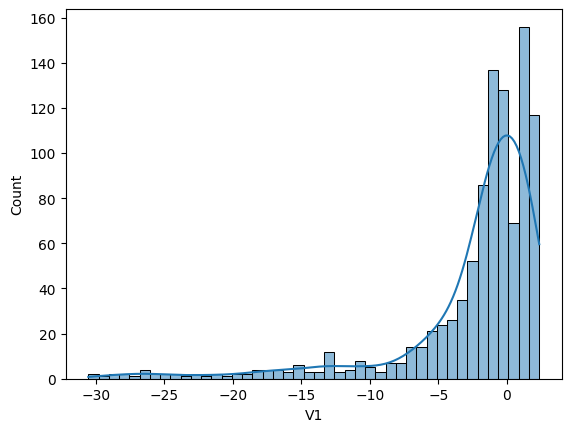

In [202]:
sns.histplot(new_df["V1"], kde=True)
plt.show()

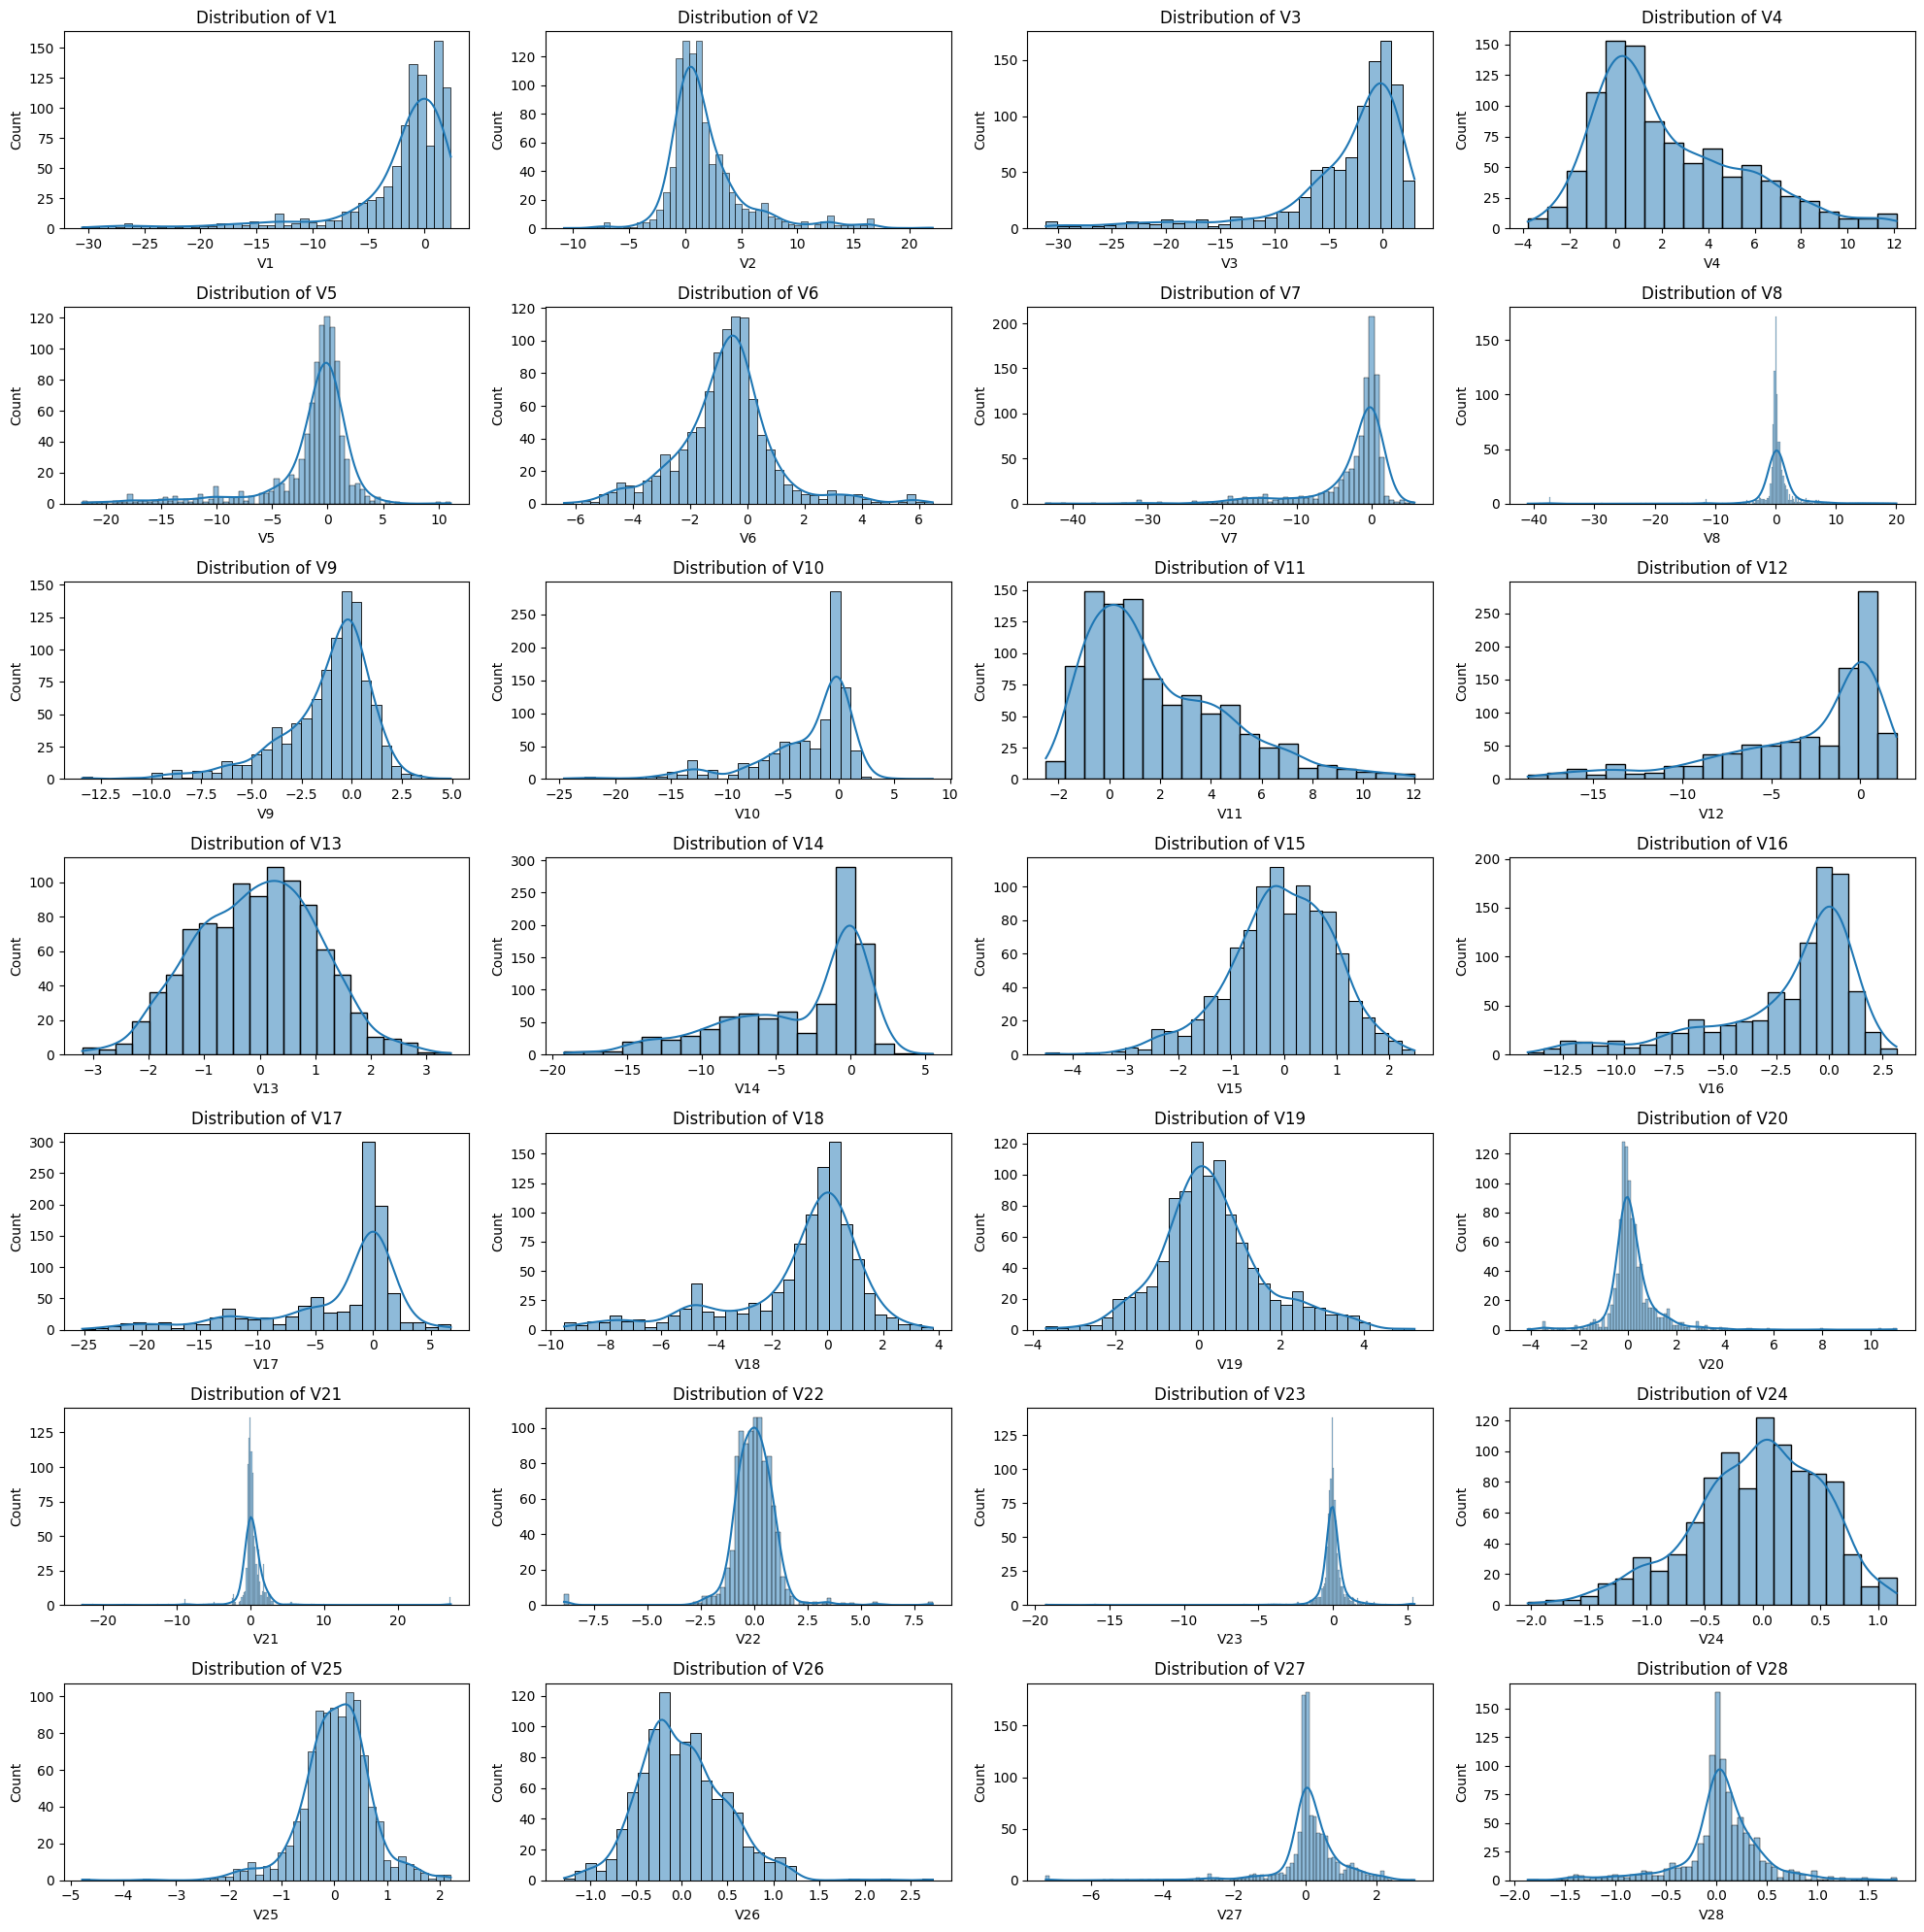

In [203]:
  

numerical_features = [f"V{i}" for i in range(1, 29)]

# Create a 7x4 grid for subplots
fig, axs = plt.subplots(7, 4, figsize=(20, 20))

# Flatten the axs array in case it's 2D (helps avoid indexing issues)
axs = axs.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(new_df[feature].dropna(), kde=True, ax=axs[i])  # Handle NaNs
    axs[i].set_title(f"Distribution of {feature}")

# Hide any unused subplots (if applicable)
for j in range(i + 1, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()


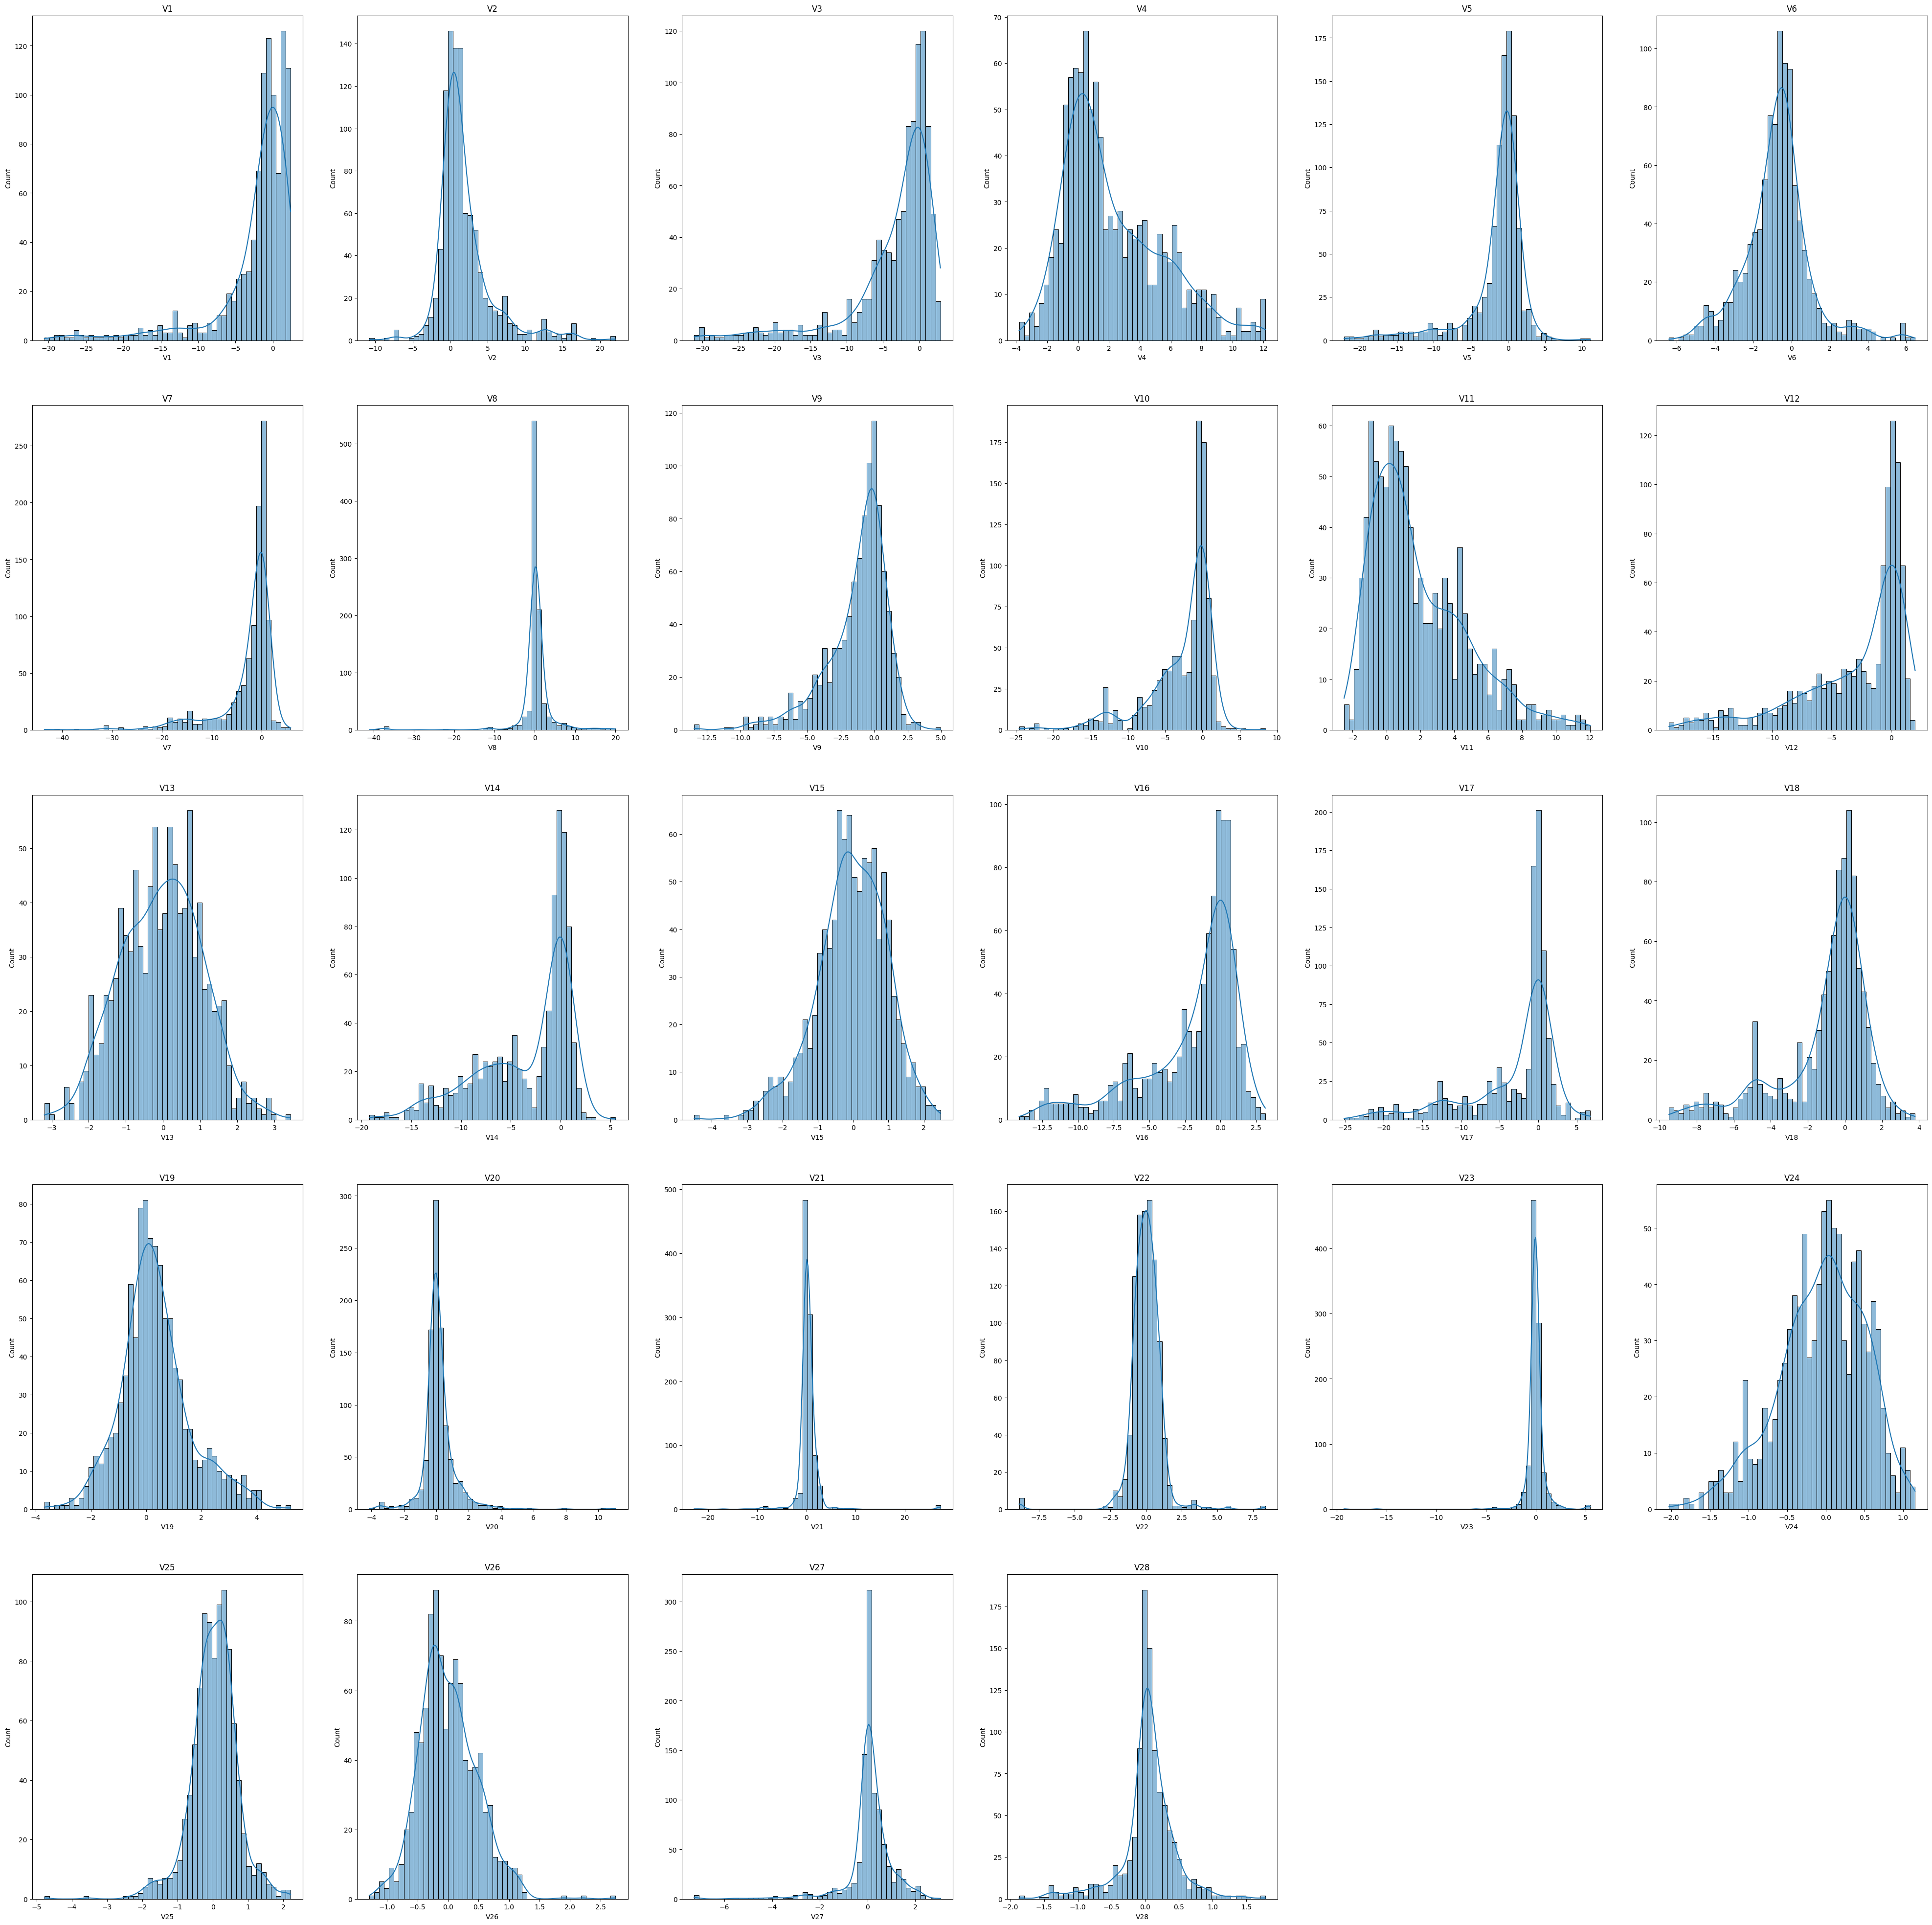

In [204]:
plt.figure(figsize=(50,50))

for i in range(1,29):
    plt.subplot(5,6,i)
    sns.histplot(new_df[f"V{i}"],bins=50,kde=True)
    plt.title(f"V{i}")
plt.show()
    

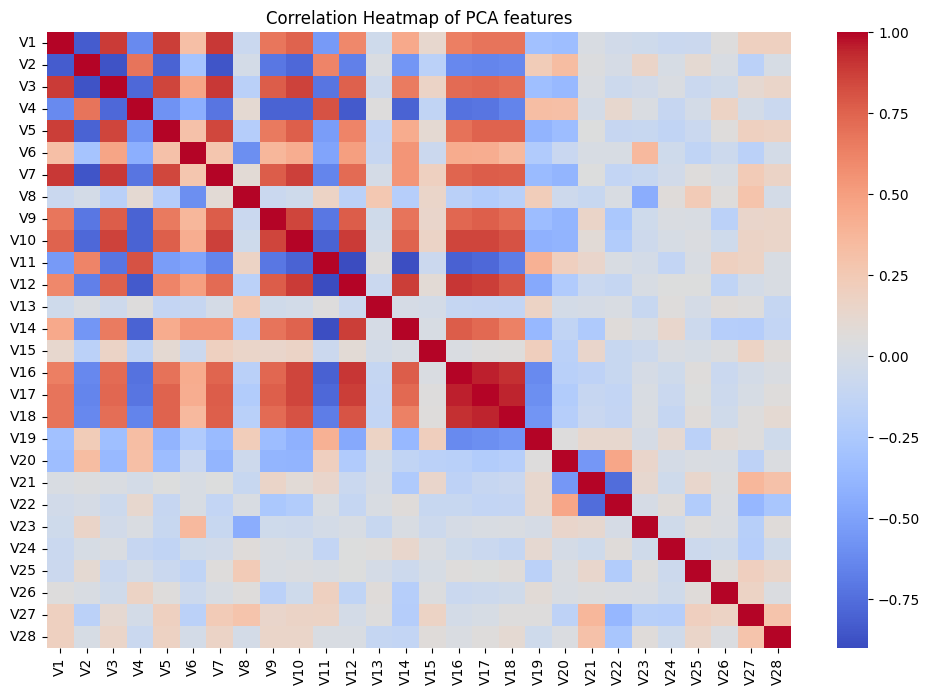

In [205]:
plt.figure(figsize=(12,8))
sns.heatmap(new_df.iloc[:,1:29].corr(),cmap='coolwarm',annot=False)
plt.title("Correlation Heatmap of PCA features")
plt.show()

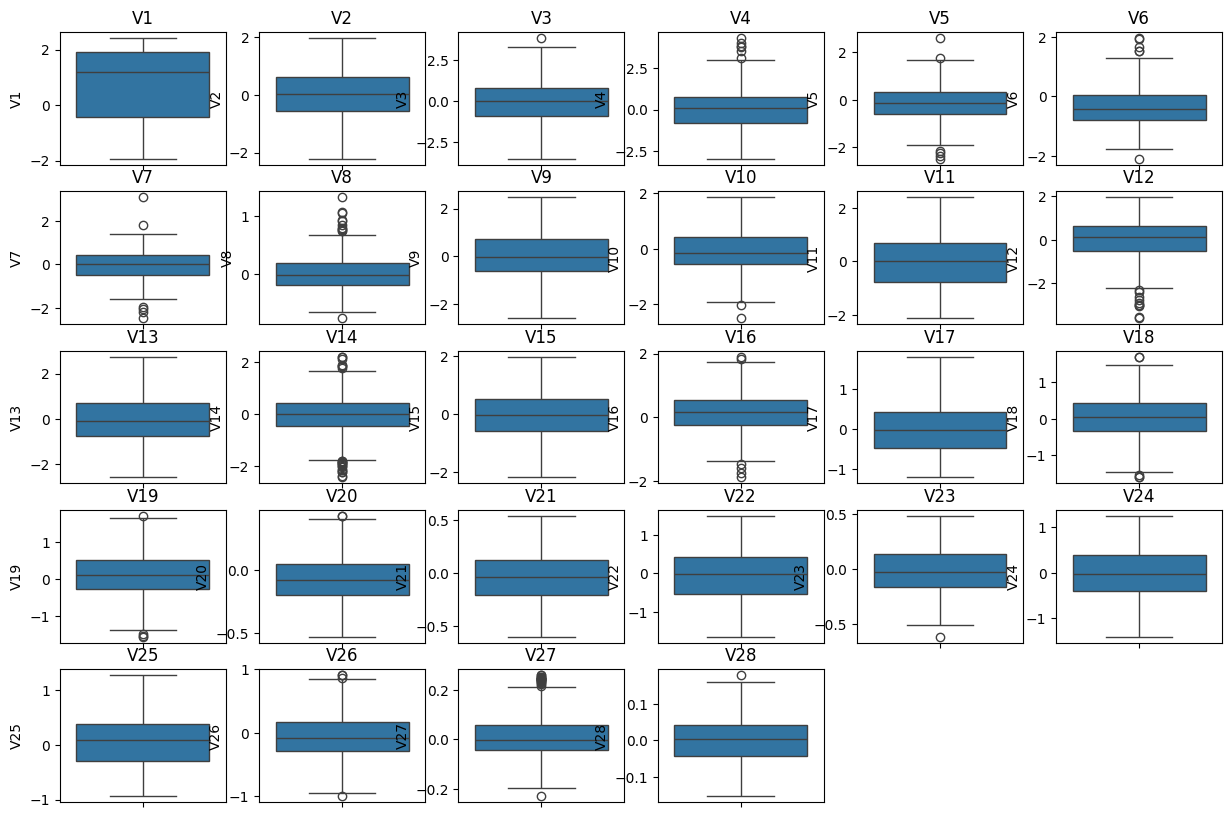

In [206]:
# Ensure cleaned_df exists by applying outlier removal if not already done
if 'cleaned_df' not in locals():
    def remove_outliers_iqr(df, columns):
        new_df = df.copy()
        for col in columns:
            Q1 = new_df[col].quantile(0.25)
            Q3 = new_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            new_df = new_df[(new_df[col] >= lower_bound) & (new_df[col] <= upper_bound)]
        return new_df
    
    columns_to_clean = [f"V{i}" for i in range(1, 29)]
    cleaned_df = remove_outliers_iqr(new_df, columns_to_clean)

# Plot boxplots for all V features
plt.figure(figsize=(15,10))
for i in range (1,29):
    plt.subplot(5,6,i)
    sns.boxplot(y=cleaned_df[f"V{i}"])
    plt.title(f"V{i}")
plt.show()

In [207]:
def remove_outliers_iqr(df, columns):
    new_df = df.copy()
    for col in columns:
        Q1 = new_df[col].quantile(0.25)
        Q3 = new_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        new_df = new_df[(new_df[col] >= lower_bound) & (new_df[col] <= upper_bound)]
    return new_df

# Assuming new_df is your original dataframe
columns_to_clean = [f"V{i}" for i in range(1, 29)]  # Columns V1 to V28
cleaned_df = remove_outliers_iqr(new_df, columns_to_clean)

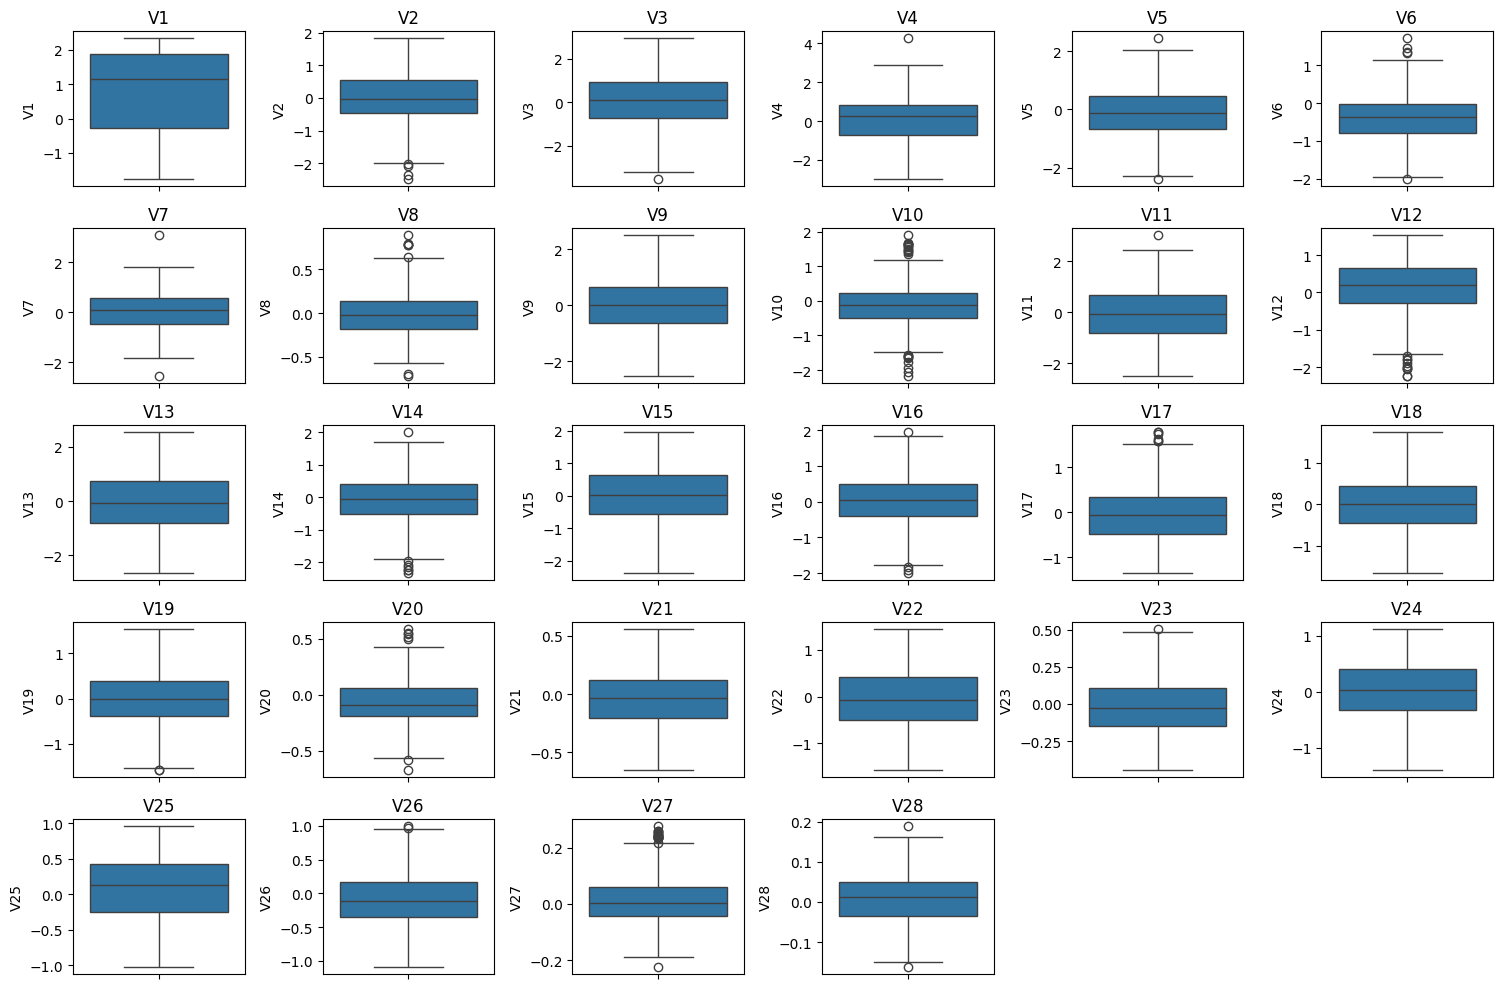

In [208]:
plt.figure(figsize=(15,10))
for i in range(1, 29):
    plt.subplot(5, 6, i)
    sns.boxplot(y=cleaned_df[f"V{i}"])
    plt.title(f"V{i}")
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15796\2199323101.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(5,6)


<Figure size 500x600 with 0 Axes>

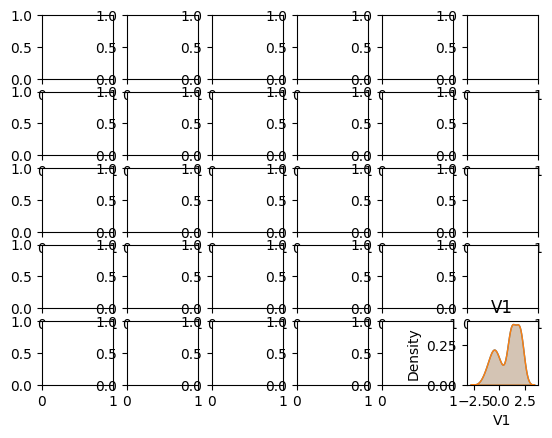

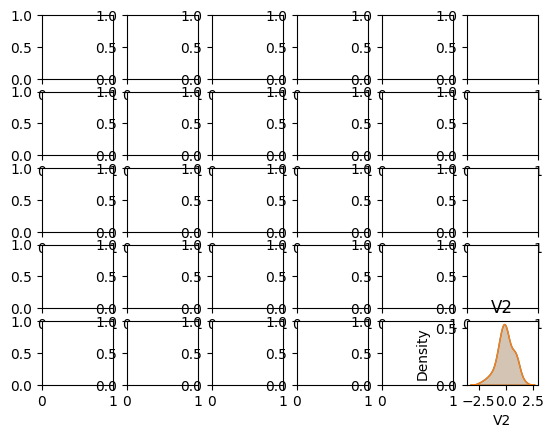

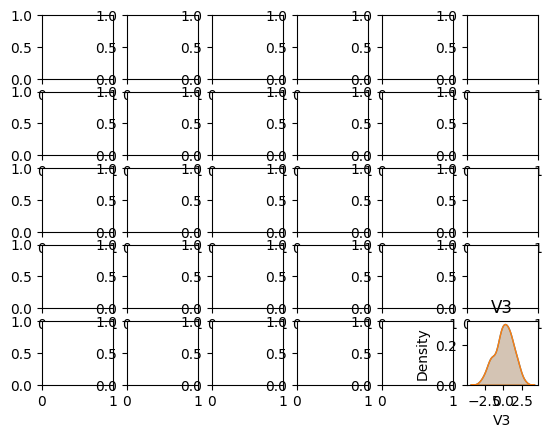

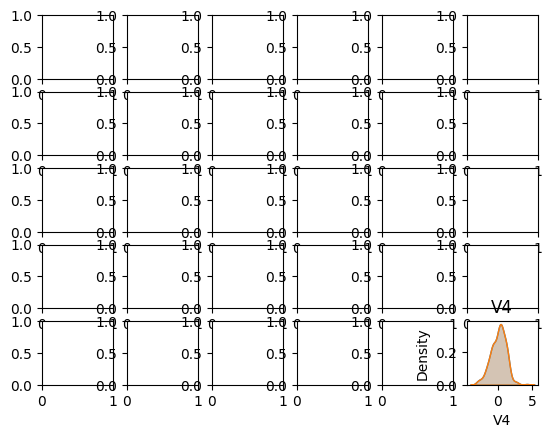

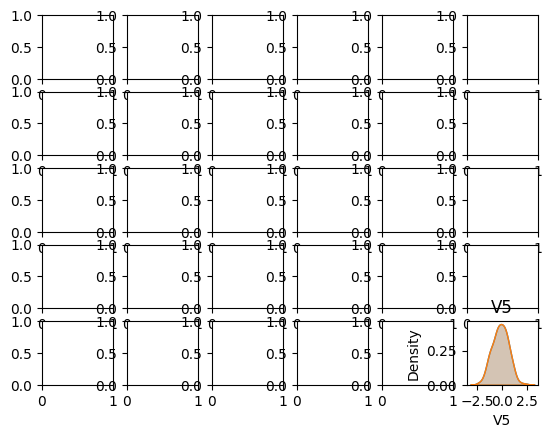

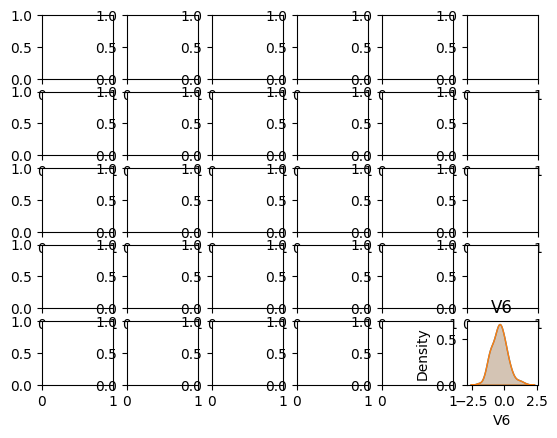

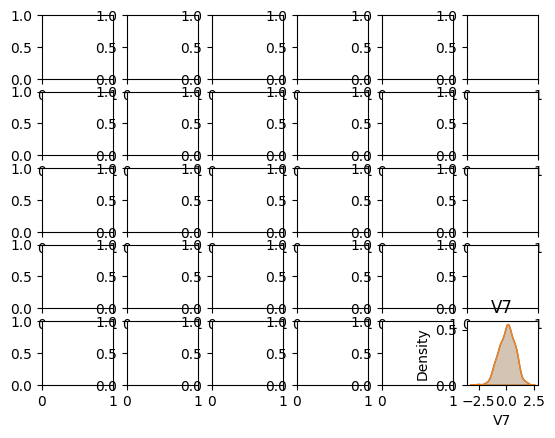

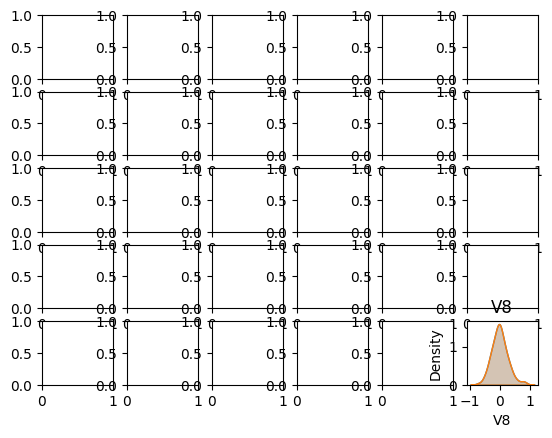

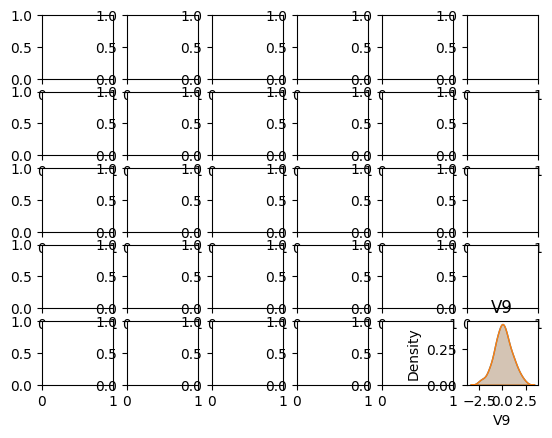

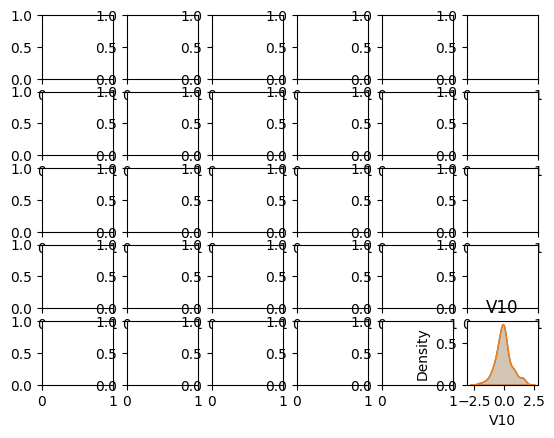

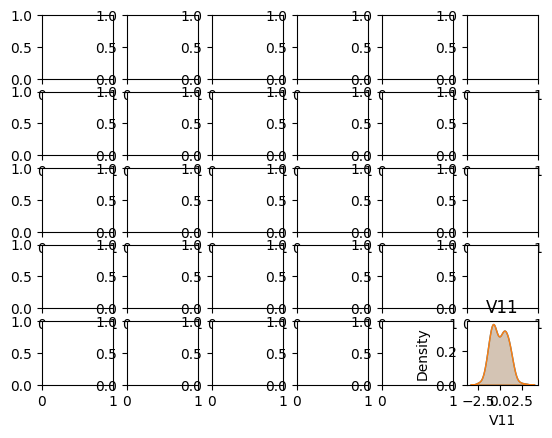

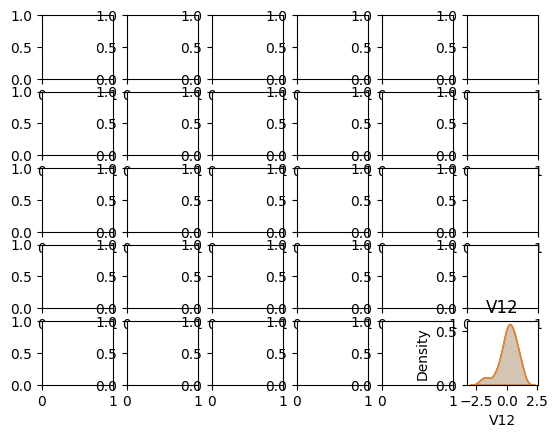

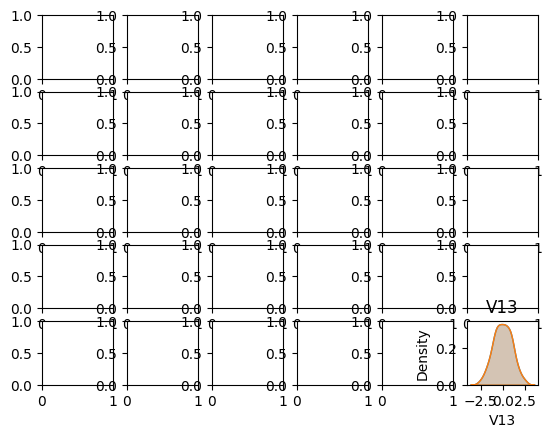

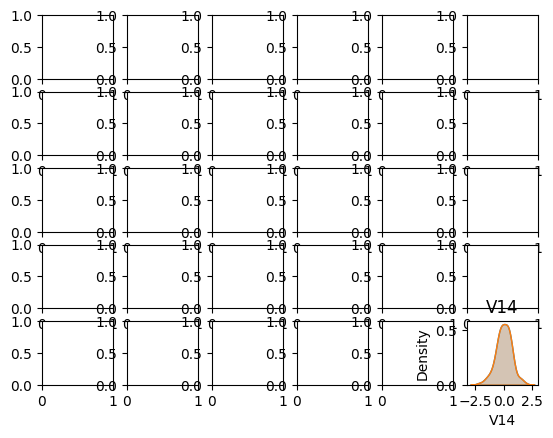

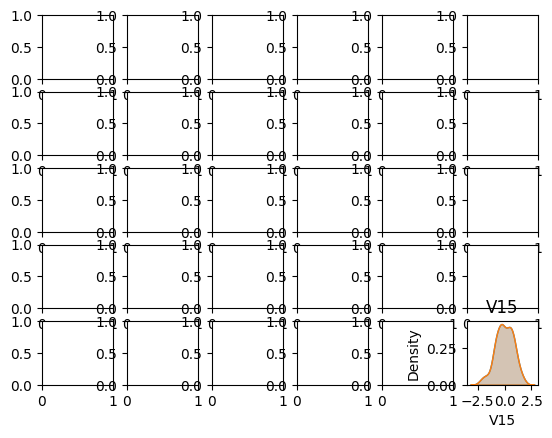

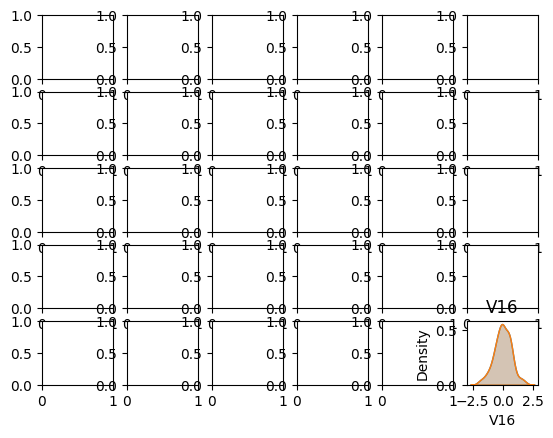

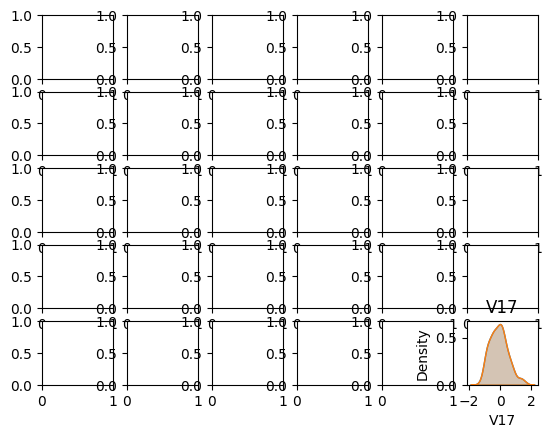

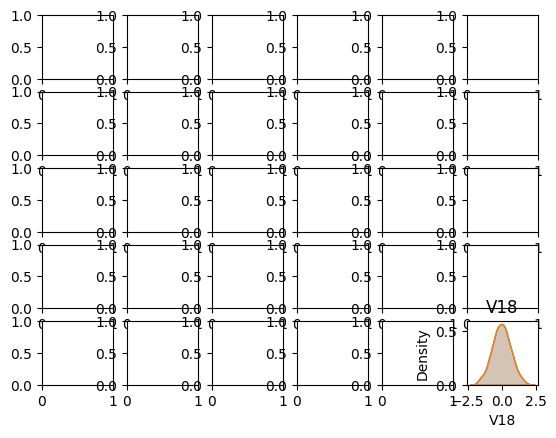

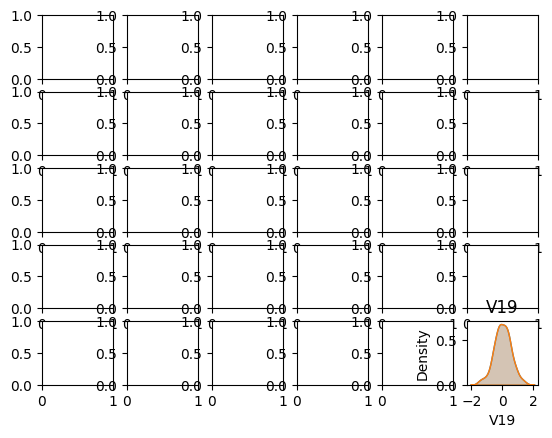

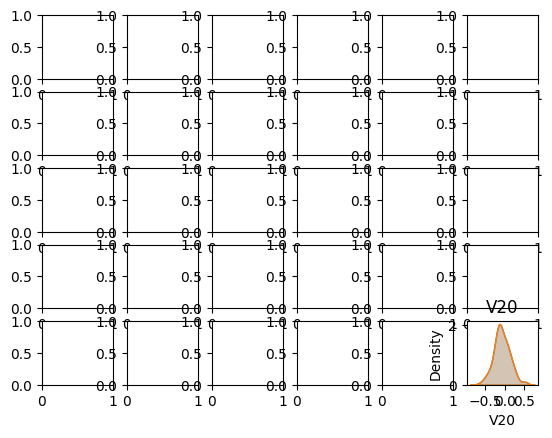

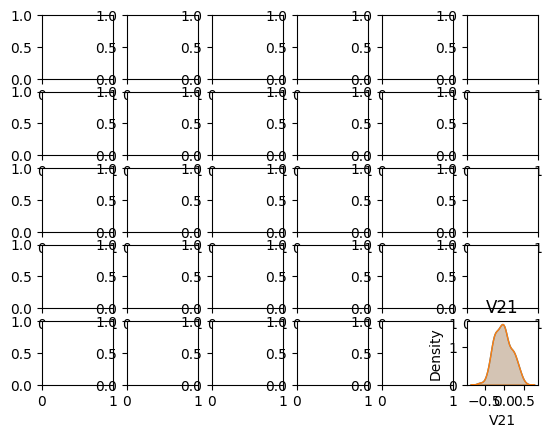

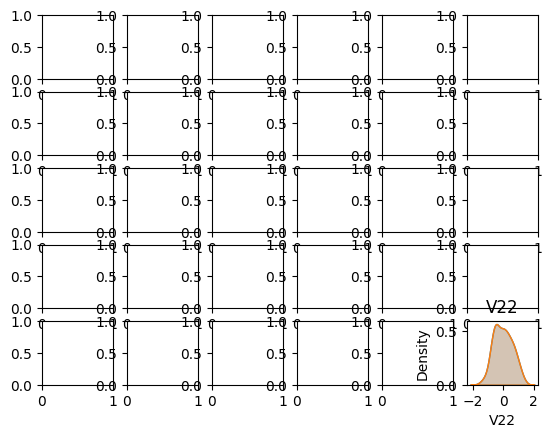

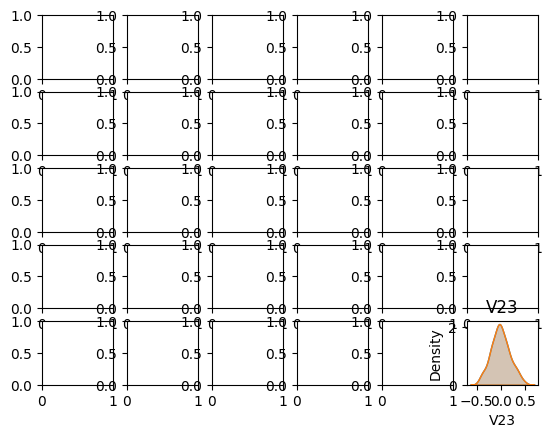

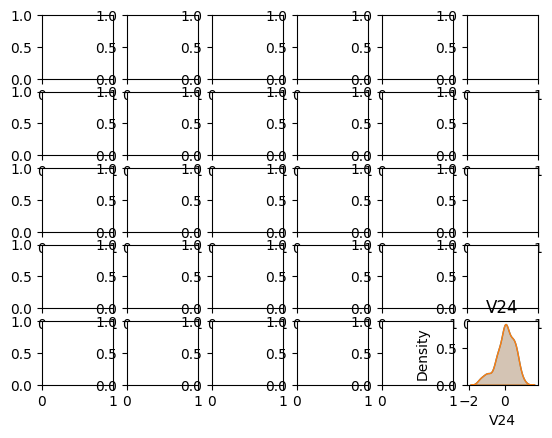

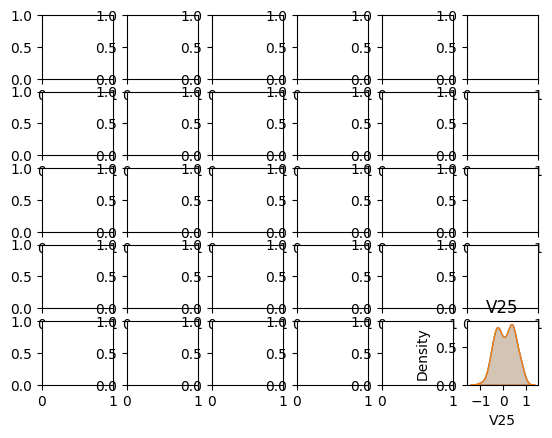

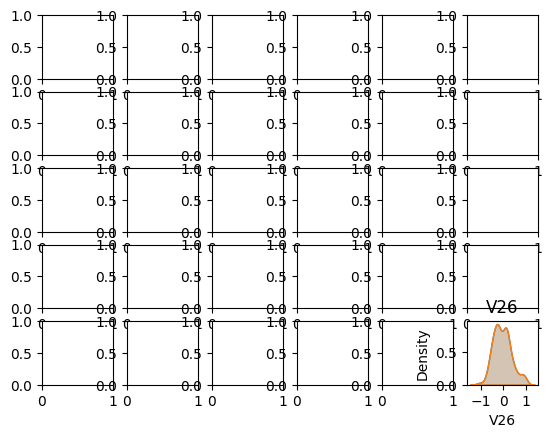

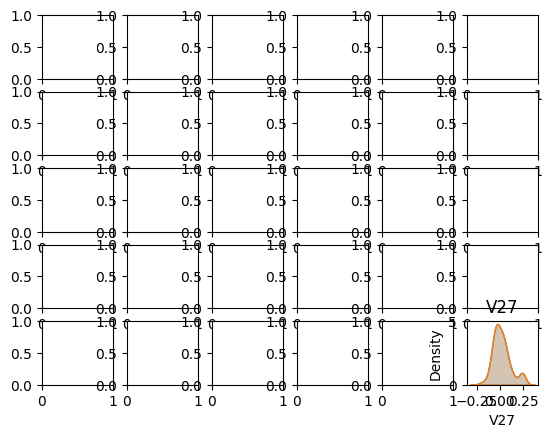

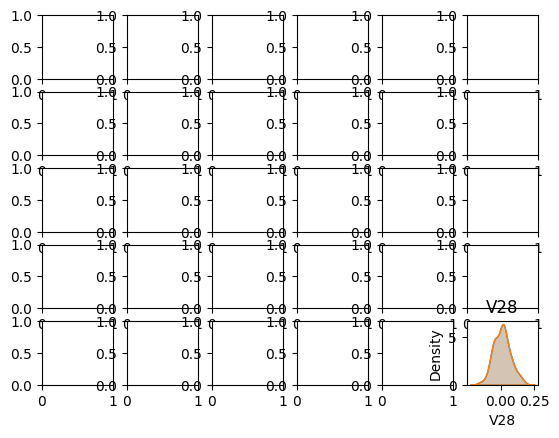

In [209]:
plt.figure(figsize=(5,6))
for i in range(1,29):
    plt.subplots(5,6)
    sns.kdeplot(cleaned_df[cleaned_df["Class"]==0][f"V{i}"],label="Non-Fraud",fill=True)
    sns.kdeplot(cleaned_df[cleaned_df["Class"]==0][f"V{i}"],label="Fraud",fill=True)
    plt.title(f"V{i}")
plt.show()


In [210]:
new_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,87657.694106,-2.327348,1.876740,-3.505777,2.270218,-1.588965,-0.734866,-2.759749,0.265678,-1.270708,...,0.339523,0.000380,-0.022876,-0.051655,0.032075,0.009652,0.092885,0.042821,99.828150,0.500000
std,48585.527713,5.509395,3.621805,6.222072,3.182285,4.177944,1.688592,5.859320,4.898289,2.312580,...,2.807593,1.166333,1.150646,0.562018,0.667890,0.468356,0.997147,0.411316,225.785734,0.500254
min,380.000000,-30.552380,-10.798133,-31.103685,-3.796899,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.289397,-7.263482,-1.869290,0.000000,0.000000
25%,45491.500000,-2.784711,-0.147729,-5.084967,-0.029758,-1.784282,-1.559753,-3.060742,-0.212060,-2.293850,...,-0.171518,-0.529639,-0.244129,-0.401342,-0.312379,-0.293111,-0.062504,-0.055474,1.572500,0.000000
50%,79556.000000,-0.717791,1.001312,-1.378969,1.282046,-0.425081,-0.645209,-0.593334,0.115896,-0.667403,...,0.122847,0.003401,-0.037575,-0.000157,0.060768,-0.033472,0.060370,0.039341,16.110000,0.500000
75%,134290.500000,1.008116,2.798885,0.353309,4.235631,0.487087,-0.009109,0.303177,0.831210,0.196780,...,0.642471,0.548894,0.181673,0.382076,0.410364,0.285233,0.461956,0.224684,99.990000,1.000000
max,172788.000000,2.365949,22.057729,2.931838,12.114672,11.095089,6.474115,5.802537,20.007208,4.942898,...,27.202839,8.361985,5.466230,1.157315,2.208209,2.745261,3.052358,1.779364,2287.200000,1.000000


In [211]:
new_df.shape

(984, 31)

In [212]:
new_df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

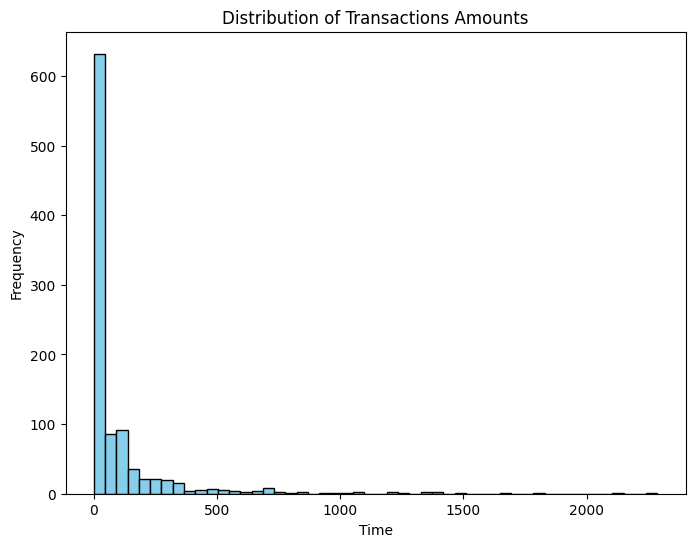

In [213]:
plt.figure(figsize=(8,6))
plt.hist(new_df['Amount'],bins=50,color='skyblue',edgecolor='black')
plt.title('Distribution of Transactions Amounts')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()


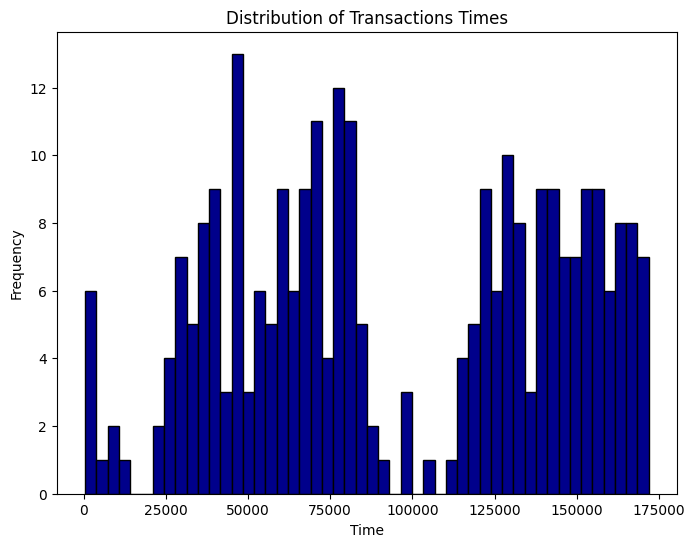

In [214]:
plt.figure(figsize=(8,6))
plt.hist(cleaned_df['Time'],bins=50,color='darkblue',edgecolor='black')
plt.title('Distribution of Transactions Times')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

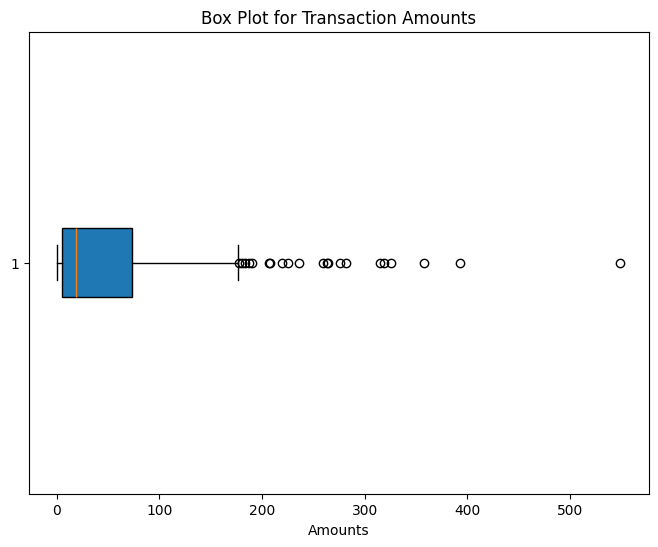

In [215]:
plt.figure(figsize=(8,6))
plt.boxplot(cleaned_df['Amount'],vert=False,patch_artist=True)
plt.title('Box Plot for Transaction Amounts')
plt.xlabel('Amounts')
plt.show()

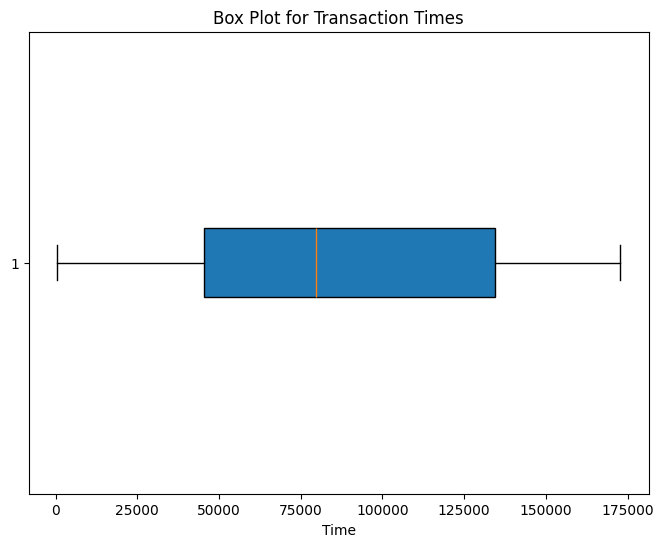

In [216]:
plt.figure(figsize=(8,6))
plt.boxplot(new_df['Time'],vert=False,patch_artist=True)
plt.title('Box Plot for Transaction Times')
plt.xlabel('Time')
plt.show()

In [217]:
IQR=new_df['Amount'].quantile(0.75)-df['Amount'].quantile(0.25)
lf=new_df['Amount'].quantile(0.25)-(IQR*3)
uf=new_df['Amount'].quantile(0.75)+(IQR*3)
print('Outliers for the amount are < {lbound} or > {ubound}'.format(lbound=lf, ubound=uf))

Outliers for the amount are < -281.5975 or > 383.16


In [218]:
cleaned_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,...,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000
mean,95541.675182,0.824145,-0.022747,0.022347,0.126021,-0.147599,-0.382551,0.047057,-0.011204,0.046590,...,-0.033440,-0.020051,-0.015031,0.006614,0.095371,-0.065743,0.016461,0.010928,54.085365,0.087591
std,48673.739610,1.095085,0.785290,1.264651,1.144821,0.827258,0.611840,0.727996,0.267316,0.953032,...,0.220855,0.600850,0.191751,0.517117,0.422890,0.396535,0.092802,0.062352,78.213704,0.283217
min,380.000000,-1.763042,-2.485334,-3.530759,-2.986832,-2.394340,-2.005974,-2.559775,-0.718871,-2.536160,...,-0.652775,-1.571166,-0.444528,-1.402547,-1.028970,-1.092479,-0.224759,-0.162619,0.000000,0.000000
25%,54715.000000,-0.275781,-0.476030,-0.741321,-0.703797,-0.684661,-0.794029,-0.475704,-0.187418,-0.629552,...,-0.203045,-0.496788,-0.149223,-0.332389,-0.251796,-0.351379,-0.043727,-0.034130,4.802500,0.000000
50%,83025.500000,1.148410,-0.031183,0.120777,0.252976,-0.121828,-0.377827,0.066821,-0.023342,0.010162,...,-0.034808,-0.067320,-0.026529,0.032952,0.132667,-0.117825,0.003533,0.011306,19.000000,0.000000
75%,141542.500000,1.868270,0.535175,0.913971,0.855224,0.442765,-0.015093,0.553859,0.141070,0.647966,...,0.117051,0.417049,0.107113,0.405182,0.430533,0.171380,0.059949,0.050324,73.705000,0.000000
max,171938.000000,2.334058,1.821537,2.931838,4.261677,2.433526,1.709384,3.071892,0.885099,2.501229,...,0.554631,1.439167,0.501614,1.109432,0.956552,0.992985,0.275702,0.188517,549.060000,1.000000


In [219]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cleaned_df['Amount'] = scaler.fit_transform(cleaned_df[['Amount']])

In [220]:
from sklearn.model_selection import train_test_split

X = cleaned_df.drop(columns='Class', axis=1)
y = cleaned_df['Class']

In [221]:
cleaned_df['Amount'].head()

18623    -0.692773
18729     2.624727
164957   -0.539066
269081   -0.681373
36535    -0.321572
Name: Amount, dtype: float64

In [222]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=2)

In [223]:
print(X.shape, X_train.shape, X_test.shape)

(274, 30) (219, 30) (55, 30)


In [224]:
#Desicion tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
DecisionTree = DecisionTreeClassifier()
DecisionTree.fit(X_train, y_train)

# Predictions
y_train_pred = DecisionTree.predict(X_train)
y_test_pred = DecisionTree.predict(X_test)

# Training set performance
dt_train_accuracy = accuracy_score(y_train, y_train_pred)
dt_train_f1 = f1_score(y_train, y_train_pred)
dt_train_precision = precision_score(y_train, y_train_pred)
dt_train_recall = recall_score(y_train, y_train_pred)
dt_train_rocauc = roc_auc_score(y_train, y_train_pred)

# Test set performance
dt_test_accuracy = accuracy_score(y_test, y_test_pred)
dt_test_f1 = f1_score(y_test, y_test_pred)
dt_test_precision = precision_score(y_test, y_test_pred)
dt_test_recall = recall_score(y_test, y_test_pred)
dt_test_rocauc = roc_auc_score(y_test, y_test_pred)

# Print
print("Decision Tree Classifier (Before Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(dt_train_accuracy))
print("- F1 score: {:.4f}".format(dt_train_f1))
print("- Precision: {:.4f}".format(dt_train_precision))
print("- Recall: {:.4f}".format(dt_train_recall))
print("- Roc Auc Score: {:.4f}".format(dt_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(dt_test_accuracy))
print("- F1 score: {:.4f}".format(dt_test_f1))
print("- Precision: {:.4f}".format(dt_test_precision))
print("- Recall: {:.4f}".format(dt_test_recall))
print("- Roc Auc Score: {:.4f}".format(dt_test_rocauc))
print("\n")


Decision Tree Classifier (Before Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.8909
- F1 score: 0.5000
- Precision: 0.5000
- Recall: 0.5000
- Roc Auc Score: 0.7194




In [225]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10, 20]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=dt_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

dt_grid.fit(X_train, y_train)

print("--------------- Best Params for Decision Tree ------------------")
print(dt_grid.best_params_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
--------------- Best Params for Decision Tree ------------------
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20}
--------------- Best Params for Decision Tree ------------------
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20}


In [226]:
# Build model with best parameters
DecisionTree_Tuned = DecisionTreeClassifier(**dt_grid.best_params_)
DecisionTree_Tuned.fit(X_train, y_train)

# Predictions
y_train_pred = DecisionTree_Tuned.predict(X_train)
y_test_pred = DecisionTree_Tuned.predict(X_test)

# Training set performance
dt_train_accuracy = accuracy_score(y_train, y_train_pred)
dt_train_f1 = f1_score(y_train, y_train_pred)
dt_train_precision = precision_score(y_train, y_train_pred)
dt_train_recall = recall_score(y_train, y_train_pred)
dt_train_rocauc = roc_auc_score(y_train, y_train_pred)

# Test set performance
dt_test_accuracy = accuracy_score(y_test, y_test_pred)
dt_test_f1 = f1_score(y_test, y_test_pred)
dt_test_precision = precision_score(y_test, y_test_pred)
dt_test_recall = recall_score(y_test, y_test_pred)
dt_test_rocauc = roc_auc_score(y_test, y_test_pred)

print("Decision Tree Classifier (After Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(dt_train_accuracy))
print("- F1 score: {:.4f}".format(dt_train_f1))
print("- Precision: {:.4f}".format(dt_train_precision))
print("- Recall: {:.4f}".format(dt_train_recall))
print("- Roc Auc Score: {:.4f}".format(dt_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(dt_test_accuracy))
print("- F1 score: {:.4f}".format(dt_test_f1))
print("- Precision: {:.4f}".format(dt_test_precision))
print("- Recall: {:.4f}".format(dt_test_recall))
print("- Roc Auc Score: {:.4f}".format(dt_test_rocauc))
print("\n")


Decision Tree Classifier (After Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9589
- F1 score: 0.7273
- Precision: 0.8000
- Recall: 0.6667
- Roc Auc Score: 0.8259

-----------------------
Model performance for Test set
- Accuracy: 0.9273
- F1 score: 0.6667
- Precision: 0.6667
- Recall: 0.6667
- Roc Auc Score: 0.8129




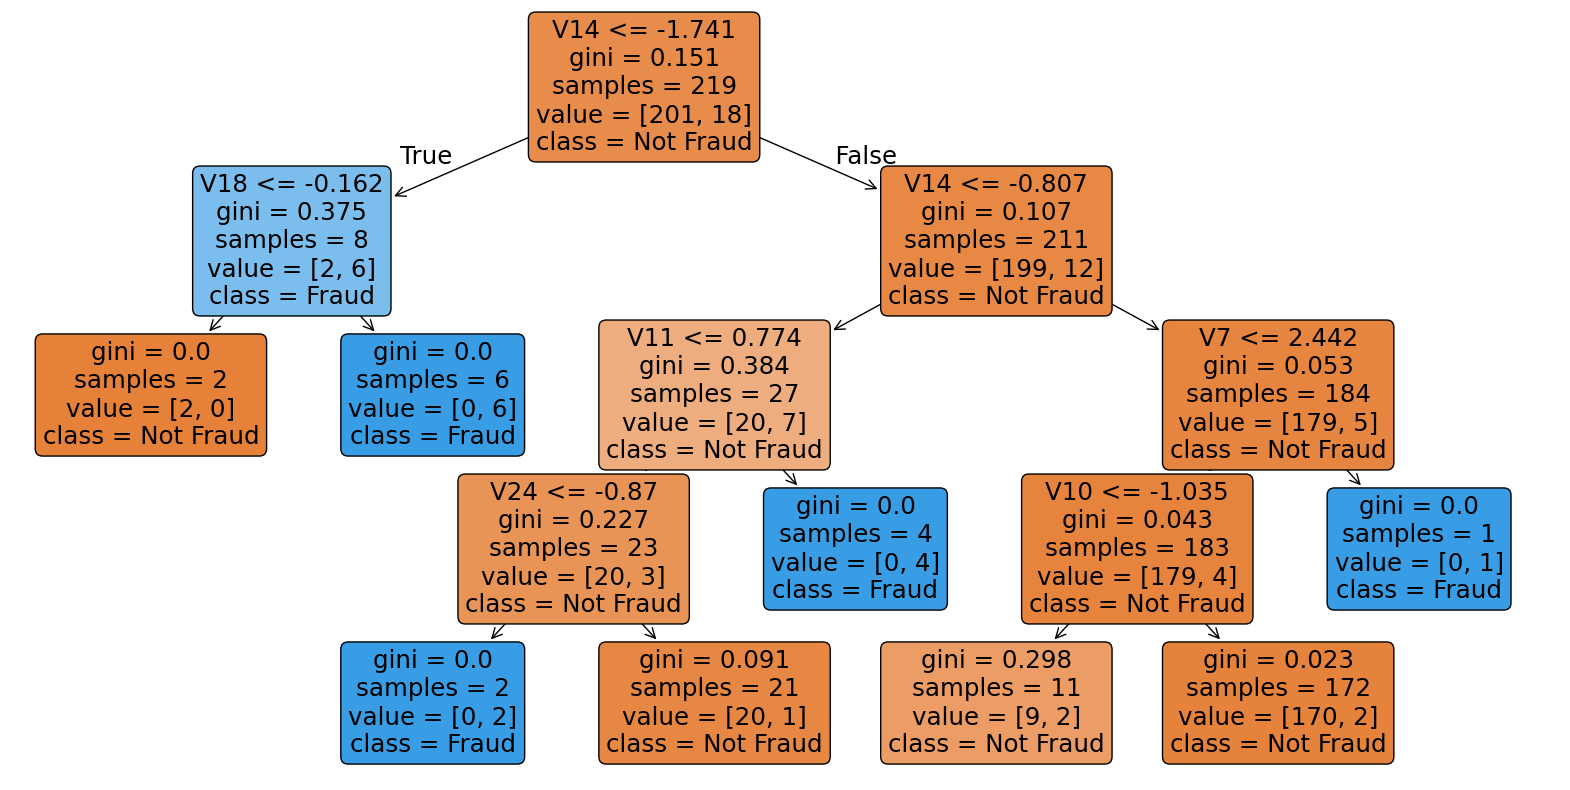

In [227]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train model
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(dt, 
          filled=True, 
          rounded=True, 
          class_names=["Not Fraud", "Fraud"], 
          feature_names=X_train.columns)
plt.show()


In [228]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
LogReg = LogisticRegression(max_iter=500)
LogReg.fit(X_train, y_train)

# Predictions
y_train_pred = LogReg.predict(X_train)
y_test_pred = LogReg.predict(X_test)

# --------------------------- Training metrics ---------------------------
log_train_accuracy = accuracy_score(y_train, y_train_pred)
log_train_f1 = f1_score(y_train, y_train_pred)
log_train_precision = precision_score(y_train, y_train_pred)
log_train_recall = recall_score(y_train, y_train_pred)
log_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
log_test_accuracy = accuracy_score(y_test, y_test_pred)
log_test_f1 = f1_score(y_test, y_test_pred)
log_test_precision = precision_score(y_test, y_test_pred)
log_test_recall = recall_score(y_test, y_test_pred)
log_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Logistic Regression (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(log_train_accuracy))
print("- F1 score: {:.4f}".format(log_train_f1))
print("- Precision: {:.4f}".format(log_train_precision))
print("- Recall: {:.4f}".format(log_train_recall))
print("- Roc Auc Score: {:.4f}".format(log_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(log_test_accuracy))
print("- F1 score: {:.4f}".format(log_test_f1))
print("- Precision: {:.4f}".format(log_test_precision))
print("- Recall: {:.4f}".format(log_test_recall))
print("- Roc Auc Score: {:.4f}".format(log_test_rocauc))
print("\n")


Logistic Regression (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9635
- F1 score: 0.7500
- Precision: 0.8571
- Recall: 0.6667
- Roc Auc Score: 0.8284

-----------------------
Model performance for Test set
- Accuracy: 0.9273
- F1 score: 0.6667
- Precision: 0.6667
- Recall: 0.6667
- Roc Auc Score: 0.8129




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [229]:
from sklearn.model_selection import GridSearchCV

log_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ['liblinear'],    # supports L1 + L2
    "max_iter": [200, 500]
}

log_grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=log_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

log_grid.fit(X_train, y_train)

print("--------------- Best Params for Logistic Regression ------------------")
print(log_grid.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
--------------- Best Params for Logistic Regression ------------------
{'C': 1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}
--------------- Best Params for Logistic Regression ------------------
{'C': 1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}


In [230]:
# Build tuned model
LogReg_Tuned = LogisticRegression(**log_grid.best_params_)
LogReg_Tuned.fit(X_train, y_train)

# Predictions
y_train_pred = LogReg_Tuned.predict(X_train)
y_test_pred = LogReg_Tuned.predict(X_test)

# --------------------------- Training metrics ---------------------------
log_train_accuracy = accuracy_score(y_train, y_train_pred)
log_train_f1 = f1_score(y_train, y_train_pred)
log_train_precision = precision_score(y_train, y_train_pred)
log_train_recall = recall_score(y_train, y_train_pred)
log_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
log_test_accuracy = accuracy_score(y_test, y_test_pred)
log_test_f1 = f1_score(y_test, y_test_pred)
log_test_precision = precision_score(y_test, y_test_pred)
log_test_recall = recall_score(y_test, y_test_pred)
log_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Logistic Regression (After Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(log_train_accuracy))
print("- F1 score: {:.4f}".format(log_train_f1))
print("- Precision: {:.4f}".format(log_train_precision))
print("- Recall: {:.4f}".format(log_train_recall))
print("- Roc Auc Score: {:.4f}".format(log_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(log_test_accuracy))
print("- F1 score: {:.4f}".format(log_test_f1))
print("- Precision: {:.4f}".format(log_test_precision))
print("- Recall: {:.4f}".format(log_test_recall))
print("- Roc Auc Score: {:.4f}".format(log_test_rocauc))
print("\n")

Logistic Regression (After Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9589
- F1 score: 0.7273
- Precision: 0.8000
- Recall: 0.6667
- Roc Auc Score: 0.8259

-----------------------
Model performance for Test set
- Accuracy: 0.9273
- F1 score: 0.6667
- Precision: 0.6667
- Recall: 0.6667
- Roc Auc Score: 0.8129




In [231]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)

# Predictions
y_train_pred = KNN.predict(X_train)
y_test_pred = KNN.predict(X_test)

# --------------------------- Training metrics ---------------------------
knn_train_accuracy = accuracy_score(y_train, y_train_pred)
knn_train_f1 = f1_score(y_train, y_train_pred)
knn_train_precision = precision_score(y_train, y_train_pred)
knn_train_recall = recall_score(y_train, y_train_pred)
knn_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
knn_test_accuracy = accuracy_score(y_test, y_test_pred)
knn_test_f1 = f1_score(y_test, y_test_pred)
knn_test_precision = precision_score(y_test, y_test_pred)
knn_test_recall = recall_score(y_test, y_test_pred)
knn_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("KNN Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(knn_train_accuracy))
print("- F1 score: {:.4f}".format(knn_train_f1))
print("- Precision: {:.4f}".format(knn_train_precision))
print("- Recall: {:.4f}".format(knn_train_recall))
print("- Roc Auc Score: {:.4f}".format(knn_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(knn_test_accuracy))
print("- F1 score: {:.4f}".format(knn_test_f1))
print("- Precision: {:.4f}".format(knn_test_precision))
print("- Recall: {:.4f}".format(knn_test_recall))
print("- Roc Auc Score: {:.4f}".format(knn_test_rocauc))
print("\n")


KNN Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9178
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000

-----------------------
Model performance for Test set
- Accuracy: 0.8909
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [232]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

knn_grid.fit(X_train, y_train)

print("--------------- Best Params for KNN ------------------")
print(knn_grid.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
--------------- Best Params for KNN ------------------
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
--------------- Best Params for KNN ------------------
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [233]:
# Build tuned KNN model
KNN_Tuned = KNeighborsClassifier(**knn_grid.best_params_)
KNN_Tuned.fit(X_train, y_train)

# Predictions
y_train_pred = KNN_Tuned.predict(X_train)
y_test_pred = KNN_Tuned.predict(X_test)

# --------------------------- Training metrics ---------------------------
knn_train_accuracy = accuracy_score(y_train, y_train_pred)
knn_train_f1 = f1_score(y_train, y_train_pred)
knn_train_precision = precision_score(y_train, y_train_pred)
knn_train_recall = recall_score(y_train, y_train_pred)
knn_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
knn_test_accuracy = accuracy_score(y_test, y_test_pred)
knn_test_f1 = f1_score(y_test, y_test_pred)
knn_test_precision = precision_score(y_test, y_test_pred)
knn_test_recall = recall_score(y_test, y_test_pred)
knn_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("KNN Classifier (After Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(knn_train_accuracy))
print("- F1 score: {:.4f}".format(knn_train_f1))
print("- Precision: {:.4f}".format(knn_train_precision))
print("- Recall: {:.4f}".format(knn_train_recall))
print("- Roc Auc Score: {:.4f}".format(knn_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(knn_test_accuracy))
print("- F1 score: {:.4f}".format(knn_test_f1))
print("- Precision: {:.4f}".format(knn_test_precision))
print("- Recall: {:.4f}".format(knn_test_recall))
print("- Roc Auc Score: {:.4f}".format(knn_test_rocauc))
print("\n")

KNN Classifier (After Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9178
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000

-----------------------
Model performance for Test set
- Accuracy: 0.8909
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [234]:
#Niave Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
NB = GaussianNB()
NB.fit(X_train, y_train)

# Predictions
y_train_pred = NB.predict(X_train)
y_test_pred = NB.predict(X_test)

# --------------------------- Training metrics ---------------------------
nb_train_accuracy = accuracy_score(y_train, y_train_pred)
nb_train_f1 = f1_score(y_train, y_train_pred)
nb_train_precision = precision_score(y_train, y_train_pred)
nb_train_recall = recall_score(y_train, y_train_pred)
nb_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
nb_test_accuracy = accuracy_score(y_test, y_test_pred)
nb_test_f1 = f1_score(y_test, y_test_pred)
nb_test_precision = precision_score(y_test, y_test_pred)
nb_test_recall = recall_score(y_test, y_test_pred)
nb_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Naive Bayes (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(nb_train_accuracy))
print("- F1 score: {:.4f}".format(nb_train_f1))
print("- Precision: {:.4f}".format(nb_train_precision))
print("- Recall: {:.4f}".format(nb_train_recall))
print("- Roc Auc Score: {:.4f}".format(nb_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(nb_test_accuracy))
print("- F1 score: {:.4f}".format(nb_test_f1))
print("- Precision: {:.4f}".format(nb_test_precision))
print("- Recall: {:.4f}".format(nb_test_recall))
print("- Roc Auc Score: {:.4f}".format(nb_test_rocauc))
print("\n")


Naive Bayes (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9269
- F1 score: 0.2727
- Precision: 0.7500
- Recall: 0.1667
- Roc Auc Score: 0.5808

-----------------------
Model performance for Test set
- Accuracy: 0.8909
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [235]:
from sklearn.model_selection import GridSearchCV

nb_params = {
    "var_smoothing": [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04]
}

nb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

nb_grid.fit(X_train, y_train)

print("--------------- Best Params for Naive Bayes ------------------")
print(nb_grid.best_params_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
--------------- Best Params for Naive Bayes ------------------
{'var_smoothing': 1e-09}
--------------- Best Params for Naive Bayes ------------------
{'var_smoothing': 1e-09}


In [236]:
# Build tuned model
NB_Tuned = GaussianNB(**nb_grid.best_params_)
NB_Tuned.fit(X_train, y_train)

# Predictions
y_train_pred = NB_Tuned.predict(X_train)
y_test_pred = NB_Tuned.predict(X_test)

# --------------------------- Training metrics ---------------------------
nb_train_accuracy = accuracy_score(y_train, y_train_pred)
nb_train_f1 = f1_score(y_train, y_train_pred)
nb_train_precision = precision_score(y_train, y_train_pred)
nb_train_recall = recall_score(y_train, y_train_pred)
nb_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
nb_test_accuracy = accuracy_score(y_test, y_test_pred)
nb_test_f1 = f1_score(y_test, y_test_pred)
nb_test_precision = precision_score(y_test, y_test_pred)
nb_test_recall = recall_score(y_test, y_test_pred)
nb_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Naive Bayes (After Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(nb_train_accuracy))
print("- F1 score: {:.4f}".format(nb_train_f1))
print("- Precision: {:.4f}".format(nb_train_precision))
print("- Recall: {:.4f}".format(nb_train_recall))
print("- Roc Auc Score: {:.4f}".format(nb_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(nb_test_accuracy))
print("- F1 score: {:.4f}".format(nb_test_f1))
print("- Precision: {:.4f}".format(nb_test_precision))
print("- Recall: {:.4f}".format(nb_test_recall))
print("- Roc Auc Score: {:.4f}".format(nb_test_rocauc))
print("\n")

Naive Bayes (After Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 0.9269
- F1 score: 0.2727
- Precision: 0.7500
- Recall: 0.1667
- Roc Auc Score: 0.5808

-----------------------
Model performance for Test set
- Accuracy: 0.8909
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.5000




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [237]:
## Implementation using RandomForest algorithm


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

# Predictions
y_train_pred = RF.predict(X_train)
y_test_pred = RF.predict(X_test)

# --------------------------- Training metrics ---------------------------
rf_train_accuracy = accuracy_score(y_train, y_train_pred)
rf_train_f1 = f1_score(y_train, y_train_pred)
rf_train_precision = precision_score(y_train, y_train_pred)
rf_train_recall = recall_score(y_train, y_train_pred)
rf_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
rf_test_accuracy = accuracy_score(y_test, y_test_pred)
rf_test_f1 = f1_score(y_test, y_test_pred)
rf_test_precision = precision_score(y_test, y_test_pred)
rf_test_recall = recall_score(y_test, y_test_pred)
rf_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Random Forest Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(rf_train_accuracy))
print("- F1 score: {:.4f}".format(rf_train_f1))
print("- Precision: {:.4f}".format(rf_train_precision))
print("- Recall: {:.4f}".format(rf_train_recall))
print("- Roc Auc Score: {:.4f}".format(rf_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(rf_test_accuracy))
print("- F1 score: {:.4f}".format(rf_test_f1))
print("- Precision: {:.4f}".format(rf_test_precision))
print("- Recall: {:.4f}".format(rf_test_recall))
print("- Roc Auc Score: {:.4f}".format(rf_test_rocauc))
print("\n")



Random Forest Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9273
- F1 score: 0.6000
- Precision: 0.7500
- Recall: 0.5000
- Roc Auc Score: 0.7398




In [238]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid=rf_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

rf_grid.fit(X_train, y_train)
print("Best Params for Random Forest:")
print(rf_grid.best_params_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Params for Random Forest:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Params for Random Forest:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [239]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

# Predictions
y_train_pred = RF.predict(X_train)
y_test_pred = RF.predict(X_test)

# --------------------------- Training metrics ---------------------------
rf_train_accuracy = accuracy_score(y_train, y_train_pred)
rf_train_f1 = f1_score(y_train, y_train_pred)
rf_train_precision = precision_score(y_train, y_train_pred)
rf_train_recall = recall_score(y_train, y_train_pred)
rf_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
rf_test_accuracy = accuracy_score(y_test, y_test_pred)
rf_test_f1 = f1_score(y_test, y_test_pred)
rf_test_precision = precision_score(y_test, y_test_pred)
rf_test_recall = recall_score(y_test, y_test_pred)
rf_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("Random Forest Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(rf_train_accuracy))
print("- F1 score: {:.4f}".format(rf_train_f1))
print("- Precision: {:.4f}".format(rf_train_precision))
print("- Recall: {:.4f}".format(rf_train_recall))
print("- Roc Auc Score: {:.4f}".format(rf_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(rf_test_accuracy))
print("- F1 score: {:.4f}".format(rf_test_f1))
print("- Precision: {:.4f}".format(rf_test_precision))
print("- Recall: {:.4f}".format(rf_test_recall))
print("- Roc Auc Score: {:.4f}".format(rf_test_rocauc))
print("\n")


Random Forest Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9091
- F1 score: 0.4444
- Precision: 0.6667
- Recall: 0.3333
- Roc Auc Score: 0.6565




In [240]:
# ADABOOST
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
ADA = AdaBoostClassifier()
ADA.fit(X_train, y_train)

# Predictions
y_train_pred = ADA.predict(X_train)
y_test_pred = ADA.predict(X_test)

# --------------------------- Training metrics ---------------------------
ada_train_accuracy = accuracy_score(y_train, y_train_pred)
ada_train_f1 = f1_score(y_train, y_train_pred)
ada_train_precision = precision_score(y_train, y_train_pred)
ada_train_recall = recall_score(y_train, y_train_pred)
ada_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
ada_test_accuracy = accuracy_score(y_test, y_test_pred)
ada_test_f1 = f1_score(y_test, y_test_pred)
ada_test_precision = precision_score(y_test, y_test_pred)
ada_test_recall = recall_score(y_test, y_test_pred)
ada_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("AdaBoost Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(ada_train_accuracy))
print("- F1 score: {:.4f}".format(ada_train_f1))
print("- Precision: {:.4f}".format(ada_train_precision))
print("- Recall: {:.4f}".format(ada_train_recall))
print("- Roc Auc Score: {:.4f}".format(ada_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(ada_test_accuracy))
print("- F1 score: {:.4f}".format(ada_test_f1))
print("- Precision: {:.4f}".format(ada_test_precision))
print("- Recall: {:.4f}".format(ada_test_recall))
print("- Roc Auc Score: {:.4f}".format(ada_test_rocauc))
print("\n")


AdaBoost Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9091
- F1 score: 0.5455
- Precision: 0.6000
- Recall: 0.5000
- Roc Auc Score: 0.7296




In [241]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

ada_params = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=ada_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

ada_grid.fit(X_train, y_train)

print("--------------- Best Params for AdaBoost ------------------")
print(ada_grid.best_params_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
--------------- Best Params for AdaBoost ------------------
{'learning_rate': 1.0, 'n_estimators': 100}
--------------- Best Params for AdaBoost ------------------
{'learning_rate': 1.0, 'n_estimators': 100}


In [242]:

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
ADA = AdaBoostClassifier()
ADA.fit(X_train, y_train)

# Predictions
y_train_pred = ADA.predict(X_train)
y_test_pred = ADA.predict(X_test)

# --------------------------- Training metrics ---------------------------
ada_train_accuracy = accuracy_score(y_train, y_train_pred)
ada_train_f1 = f1_score(y_train, y_train_pred)
ada_train_precision = precision_score(y_train, y_train_pred)
ada_train_recall = recall_score(y_train, y_train_pred)
ada_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
ada_test_accuracy = accuracy_score(y_test, y_test_pred)
ada_test_f1 = f1_score(y_test, y_test_pred)
ada_test_precision = precision_score(y_test, y_test_pred)
ada_test_recall = recall_score(y_test, y_test_pred)
ada_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("AdaBoost Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(ada_train_accuracy))
print("- F1 score: {:.4f}".format(ada_train_f1))
print("- Precision: {:.4f}".format(ada_train_precision))
print("- Recall: {:.4f}".format(ada_train_recall))
print("- Roc Auc Score: {:.4f}".format(ada_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(ada_test_accuracy))
print("- F1 score: {:.4f}".format(ada_test_f1))
print("- Precision: {:.4f}".format(ada_test_precision))
print("- Recall: {:.4f}".format(ada_test_recall))
print("- Roc Auc Score: {:.4f}".format(ada_test_rocauc))
print("\n")


AdaBoost Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9091
- F1 score: 0.5455
- Precision: 0.6000
- Recall: 0.5000
- Roc Auc Score: 0.7296




In [243]:
%pip install xgboost



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [244]:
# XGBOOST
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
XGB = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
XGB.fit(X_train, y_train)

# Predictions
y_train_pred = XGB.predict(X_train)
y_test_pred = XGB.predict(X_test)

# --------------------------- Training metrics ---------------------------
xgb_train_accuracy = accuracy_score(y_train, y_train_pred)
xgb_train_f1 = f1_score(y_train, y_train_pred)
xgb_train_precision = precision_score(y_train, y_train_pred)
xgb_train_recall = recall_score(y_train, y_train_pred)
xgb_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
xgb_test_accuracy = accuracy_score(y_test, y_test_pred)
xgb_test_f1 = f1_score(y_test, y_test_pred)
xgb_test_precision = precision_score(y_test, y_test_pred)
xgb_test_recall = recall_score(y_test, y_test_pred)
xgb_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("XGBoost Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(xgb_train_accuracy))
print("- F1 score: {:.4f}".format(xgb_train_f1))
print("- Precision: {:.4f}".format(xgb_train_precision))
print("- Recall: {:.4f}".format(xgb_train_recall))
print("- Roc Auc Score: {:.4f}".format(xgb_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(xgb_test_accuracy))
print("- F1 score: {:.4f}".format(xgb_test_f1))
print("- Precision: {:.4f}".format(xgb_test_precision))
print("- Recall: {:.4f}".format(xgb_test_recall))
print("- Roc Auc Score: {:.4f}".format(xgb_test_rocauc))
print("\n")


XGBoost Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9091
- F1 score: 0.5455
- Precision: 0.6000
- Recall: 0.5000
- Roc Auc Score: 0.7296




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [09:44:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [245]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_params,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="f1"
)

xgb_grid.fit(X_train, y_train)

print("--------------- Best Params for XGBoost ------------------")
print(xgb_grid.best_params_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
--------------- Best Params for XGBoost ------------------
{'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
--------------- Best Params for XGBoost ------------------
{'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [09:44:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [246]:
# XGBOOST
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
XGB = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
XGB.fit(X_train, y_train)

# Predictions
y_train_pred = XGB.predict(X_train)
y_test_pred = XGB.predict(X_test)

# --------------------------- Training metrics ---------------------------
xgb_train_accuracy = accuracy_score(y_train, y_train_pred)
xgb_train_f1 = f1_score(y_train, y_train_pred)
xgb_train_precision = precision_score(y_train, y_train_pred)
xgb_train_recall = recall_score(y_train, y_train_pred)
xgb_train_rocauc = roc_auc_score(y_train, y_train_pred)

# --------------------------- Testing metrics ----------------------------
xgb_test_accuracy = accuracy_score(y_test, y_test_pred)
xgb_test_f1 = f1_score(y_test, y_test_pred)
xgb_test_precision = precision_score(y_test, y_test_pred)
xgb_test_recall = recall_score(y_test, y_test_pred)
xgb_test_rocauc = roc_auc_score(y_test, y_test_pred)

# --------------------------- Print -------------------------------------
print("XGBoost Classifier (Before Hyperparameter Tuning)")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(xgb_train_accuracy))
print("- F1 score: {:.4f}".format(xgb_train_f1))
print("- Precision: {:.4f}".format(xgb_train_precision))
print("- Recall: {:.4f}".format(xgb_train_recall))
print("- Roc Auc Score: {:.4f}".format(xgb_train_rocauc))

print("\n-----------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(xgb_test_accuracy))
print("- F1 score: {:.4f}".format(xgb_test_f1))
print("- Precision: {:.4f}".format(xgb_test_precision))
print("- Recall: {:.4f}".format(xgb_test_recall))
print("- Roc Auc Score: {:.4f}".format(xgb_test_rocauc))
print("\n")


XGBoost Classifier (Before Hyperparameter Tuning)
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000

-----------------------
Model performance for Test set
- Accuracy: 0.9091
- F1 score: 0.5455
- Precision: 0.6000
- Recall: 0.5000
- Roc Auc Score: 0.7296




c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [09:45:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [250]:
import pandas as pd

summary_data = {
    "Algorithm": [
        "Decision Tree",
        "Logistic Regression",
        "KNN",
        "Naive Bayes",
        "Random Forest",
        "AdaBoost",
        "XGBoost"
    ],
    "Train Accuracy": [
        dt_train_accuracy,
        log_train_accuracy,
        knn_train_accuracy,
        nb_train_accuracy,
        rf_train_accuracy,
        ada_train_accuracy,
        xgb_train_accuracy
    ],
    "Test Accuracy": [
        dt_test_accuracy,
        log_test_accuracy,
        knn_test_accuracy,
        nb_test_accuracy,
        # svm_test_accuracy,
        rf_test_accuracy,
        ada_test_accuracy,
        xgb_test_accuracy
    ],
    "Train Precision": [
        dt_train_precision,
        log_train_precision,
        knn_train_precision,
        nb_train_precision,
        # svm_train_precision,
        rf_train_precision,
        ada_train_precision,
        xgb_train_precision
    ],
    "Test Precision": [
        dt_test_precision,
        log_test_precision,
        knn_test_precision,
        nb_test_precision,
        # svm_test_precision,
        rf_test_precision,
        ada_test_precision,
        xgb_test_precision
    ],
    "Train Recall": [
        dt_train_recall,
        log_train_recall,
        knn_train_recall,
        nb_train_recall,
        # svm_train_recall,
        rf_train_recall,
        ada_train_recall,
        xgb_train_recall
    ],
    "Test Recall": [
        dt_test_recall,
        log_test_recall,
        knn_test_recall,
        nb_test_recall,
        # svm_test_recall,
        rf_test_recall,
        ada_test_recall,
        xgb_test_recall
    ],
    "Train F1 Score": [
        dt_train_f1,
        log_train_f1,
        knn_train_f1,
        nb_train_f1,
        # svm_train_f1,
        rf_train_f1,
        ada_train_f1,
        xgb_train_f1
    ],
    "Test F1 Score": [
        dt_test_f1,
        log_test_f1,
        knn_test_f1,
        nb_test_f1,
        # svm_test_f1,
        rf_test_f1,
        ada_test_f1,
        xgb_test_f1
    ],
    "Train ROC-AUC": [
        dt_train_rocauc,
        log_train_rocauc,
        knn_train_rocauc,
        nb_train_rocauc,
        # svm_train_rocauc,
        rf_train_rocauc,
        ada_train_rocauc,
        xgb_train_rocauc
    ],
    "Test ROC-AUC": [
        dt_test_rocauc,
        log_test_rocauc,
        knn_test_rocauc,
        nb_test_rocauc,
        # svm_test_rocauc,
        rf_test_rocauc,
        ada_test_rocauc,
        xgb_test_rocauc
    ]
}

summary_df = pd.DataFrame(summary_data)

# Beautiful formatting for Jupyter Notebook
summary_df.style.background_gradient(cmap="Greens")


,Algorithm,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train ROC-AUC,Test ROC-AUC
0,Decision Tree,0.958904,0.927273,0.800000,0.666667,0.666667,0.666667,0.727273,0.666667,0.825871,0.812925
1,Logistic Regression,0.958904,0.927273,0.800000,0.666667,0.666667,0.666667,0.727273,0.666667,0.825871,0.812925
2,KNN,0.917808,0.890909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000
3,Naive Bayes,0.926941,0.890909,0.750000,0.000000,0.166667,0.000000,0.272727,0.000000,0.580846,0.500000
4,Random Forest,1.000000,0.909091,1.000000,0.666667,1.000000,0.333333,1.000000,0.444444,1.000000,0.656463
5,AdaBoost,1.000000,0.909091,1.000000,0.600000,1.000000,0.500000,1.000000,0.545455,1.000000,0.729592
6,XGBoost,1.000000,0.909091,1.000000,0.600000,1.000000,0.500000,1.000000,0.545455,1.000000,0.729592
